In [4]:
pip install ipywidgets jupyterlab_widgets

Defaulting to user installation because normal site-packages is not writeable
  Obtaining dependency information for ipywidgets from https://files.pythonhosted.org/packages/56/6d/0d9848617b9f753b87f214f1c682592f7ca42de085f564352f10f0843026/ipywidgets-8.1.8-py3-none-any.whl.metadata
  Obtaining dependency information for jupyterlab_widgets from https://files.pythonhosted.org/packages/ab/b5/36c712098e6191d1b4e349304ef73a8d06aed77e56ceaac8c0a306c7bda1/jupyterlab_widgets-3.0.16-py3-none-any.whl.metadata
  Obtaining dependency information for widgetsnbextension~=4.0.14 from https://files.pythonhosted.org/packages/3f/0e/fa3b193432cfc60c93b42f3be03365f5f909d2b3ea410295cf36df739e31/widgetsnbextension-4.0.15-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/139.8 kB ? eta -:--:--
   ----- ---------------------------------- 20.5/139.8 kB ? eta -:--:--
   ------------------- ------------------- 71.7/139.8 kB 991.0 kB/s eta 0:00:01
   ------------------------------------ - 

DEPRECATION: Loading egg at c:\program files\python311\lib\site-packages\vboxapi-1.0-py3.11.egg is deprecated. pip 23.3 will enforce this behaviour change. A possible replacement is to use pip for package installation..

[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
!jupyter nbextension enable --py widgetsnbextension


usage: jupyter [-h] [--version] [--config-dir] [--data-dir] [--runtime-dir]
               [--paths] [--json] [--debug]
               [subcommand]

Jupyter: Interactive Computing

positional arguments:
  subcommand     the subcommand to launch

options:
  -h, --help     show this help message and exit
  --version      show the versions of core jupyter packages and exit
  --config-dir   show Jupyter config dir
  --data-dir     show Jupyter data dir
  --runtime-dir  show Jupyter runtime dir
  --paths        show all Jupyter paths. Add --json for machine-readable
                 format.
  --json         output paths as machine-readable json
  --debug        output debug information about paths

Available subcommands: dejavu events execute kernel kernelspec lab
labextension labhub migrate nbconvert notebook run server troubleshoot trust

Jupyter command `jupyter-nbextension` not found.


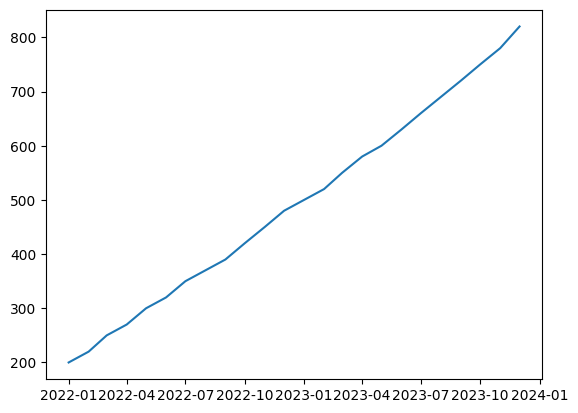

In [8]:
plt.plot(data['Date'], data['Sales'])
plt.show()

In [9]:
!pip install pandas

Defaulting to user installation because normal site-packages is not writeable


DEPRECATION: Loading egg at c:\program files\python311\lib\site-packages\vboxapi-1.0-py3.11.egg is deprecated. pip 23.3 will enforce this behaviour change. A possible replacement is to use pip for package installation..

[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


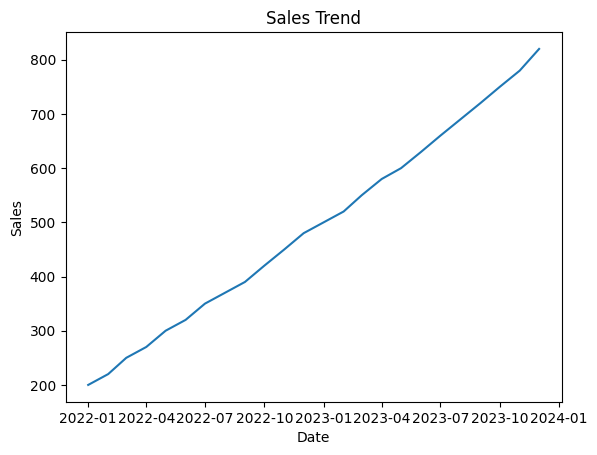

In [10]:
import matplotlib.pyplot as plt

plt.plot(data['Date'], data['Sales'])
plt.title("Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

In [11]:
df = data[['Date', 'Sales']]
df.columns = ['ds', 'y']

df.head()

,ds,y
0,2022-01-01,200
1,2022-02-01,220
2,2022-03-01,250
3,2022-04-01,270
4,2022-05-01,300


In [12]:
from prophet import Prophet

model = Prophet()
model.fit(df)

13:06:48 - cmdstanpy - INFO - Chain [1] start processing
13:06:49 - cmdstanpy - INFO - Chain [1] done processing


In [14]:
future = model.make_future_dataframe(periods=6, freq='ME')
forecast = model.predict(future)

forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
25,2024-01-31,875.939517,871.571663,880.465579,875.146158,876.744107,0.0,0.0,0.0,0.0,0.0,0.0,875.939517
26,2024-02-29,905.385069,900.732043,910.081451,903.844304,906.960599,0.0,0.0,0.0,0.0,0.0,0.0,905.385069
27,2024-03-31,936.861349,931.717167,941.824494,934.480020,939.311005,0.0,0.0,0.0,0.0,0.0,0.0,936.861349
28,2024-04-30,967.322264,961.978197,972.948966,964.016639,970.813229,0.0,0.0,0.0,0.0,0.0,0.0,967.322264
29,2024-05-31,998.798544,992.903690,1005.665693,994.710290,1003.389235,0.0,0.0,0.0,0.0,0.0,0.0,998.798544


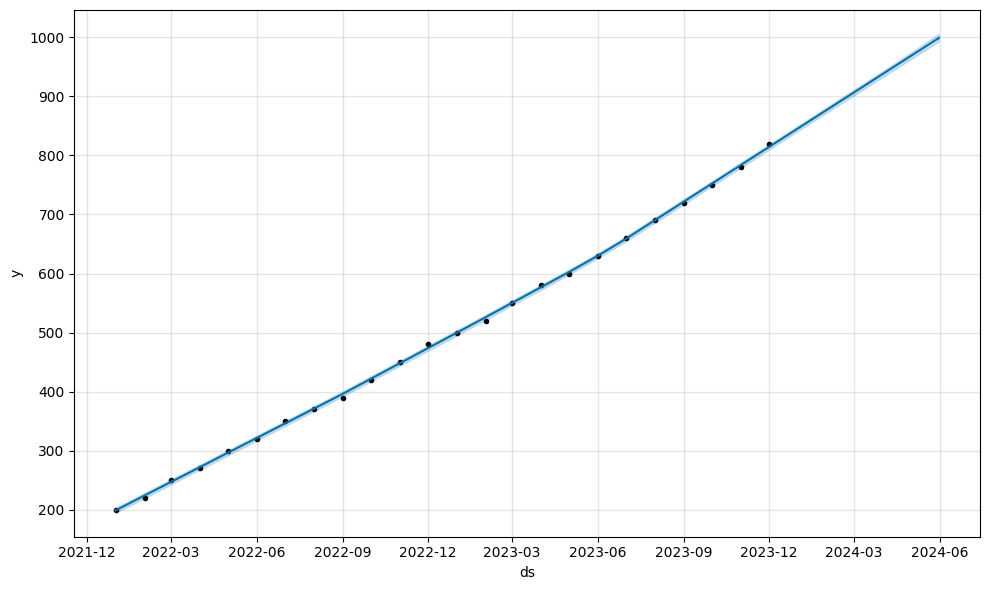

In [15]:
model.plot(forecast)
plt.show()

In [16]:
from sklearn.metrics import mean_absolute_error

predicted = forecast['yhat'][:len(df)]
mae = mean_absolute_error(df['y'], predicted)

print("MAE:", mae)

MAE: 2.6605073099427323


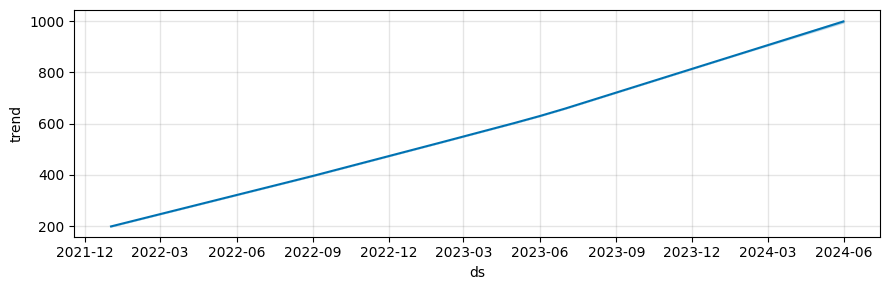

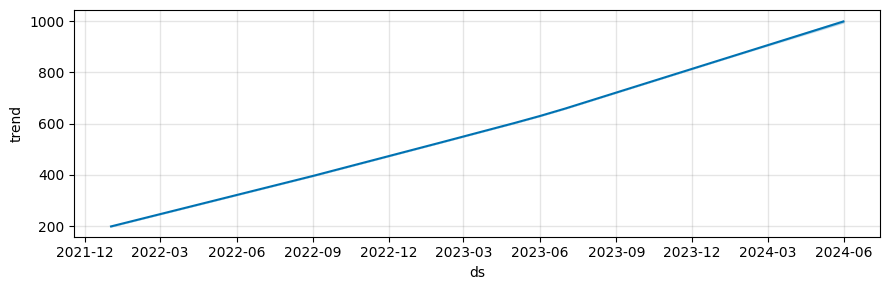

In [17]:
model.plot_components(forecast)